# US Visa Prediction Project

Machine learning life cycle <br>
1. Understand the problem statement
2. Data collection
3. Exploratory data analysis
4. Data cleaning
5. Model pre-processing
6. Model training
7. choose best Model


## 1) Problem statement.

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

2. Data Collection <br>
https://www.kaggle.com/datasets/moro23/easyvisa-dataset

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings


In [103]:
warnings.filterwarnings("ignore")

%matplotlib inline

In [104]:
df=pd.read_csv(r"C:\Inception BD\ML Project\end-to-end-machine-learning-project-Visa-approval-prediction-\notebook\EasyVisa.csv")

In [105]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [106]:
df.shape

(25480, 12)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [108]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


* Exploring Data

In [109]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O'] #define numerical columns
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O'] #define categorical columns

In [110]:
#print columns
print('i have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('i have {} categorical features: {}'.format(len(categorical_features), categorical_features))

i have 3 numerical features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
i have 9 categorical features: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [111]:
# now i need to convert categorical data to numerical data (proportion)
#if a column values are very unique then it is not important helpful for our analysis data, we can remove it
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('---------------------------------------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype:

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

** Univariate Analysis ** <br>
-> Here Uni means one.<br>
-> Univarite analysis means to understand the distribution of values for a single variable <br>

* **Bivariate Analysis:** The analysis of two variables/columns.
* **Multivariate Analysis:** The analysis of two or more variables/columns.

** Numerical Features **

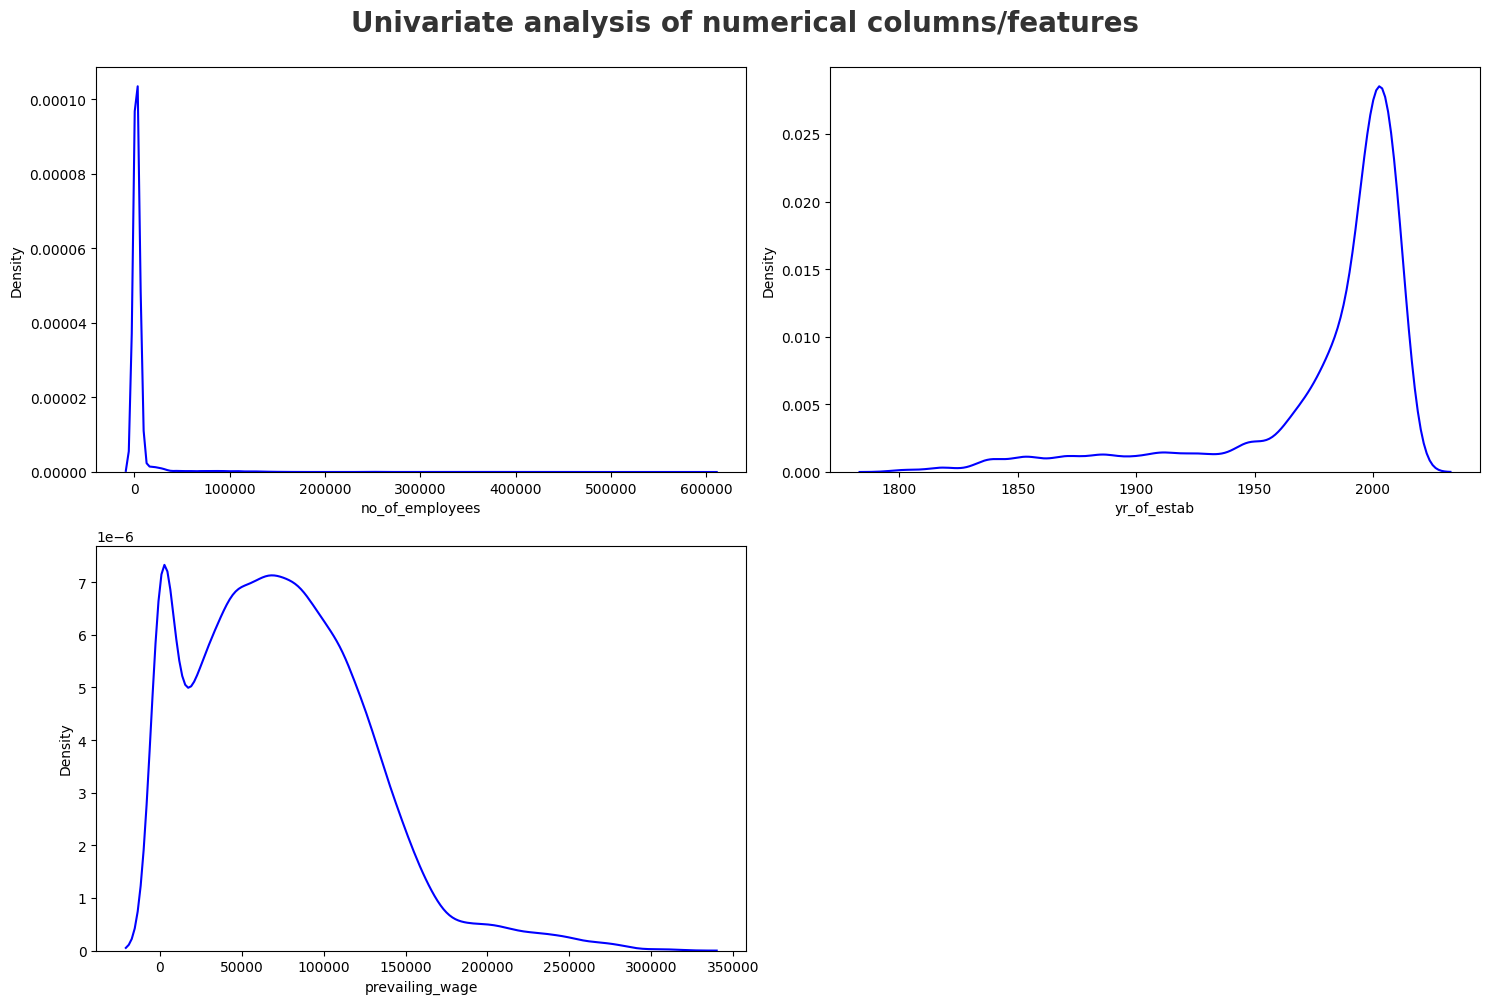

In [112]:
plt.figure(figsize=(15,10))
plt.suptitle('Univariate analysis of numerical columns/features', fontweight='bold', fontsize=20, alpha=0.8, y=1.)

for i in range (0,len(numeric_features)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(x=df[numeric_features[i]],color='blue')
    plt.tight_layout()

* here number of employes right-squid, number of year estab is left-squid
* machine learning good for normal distribution <br> <br>
**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-wage` is a right-skewed distribution.

In [113]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

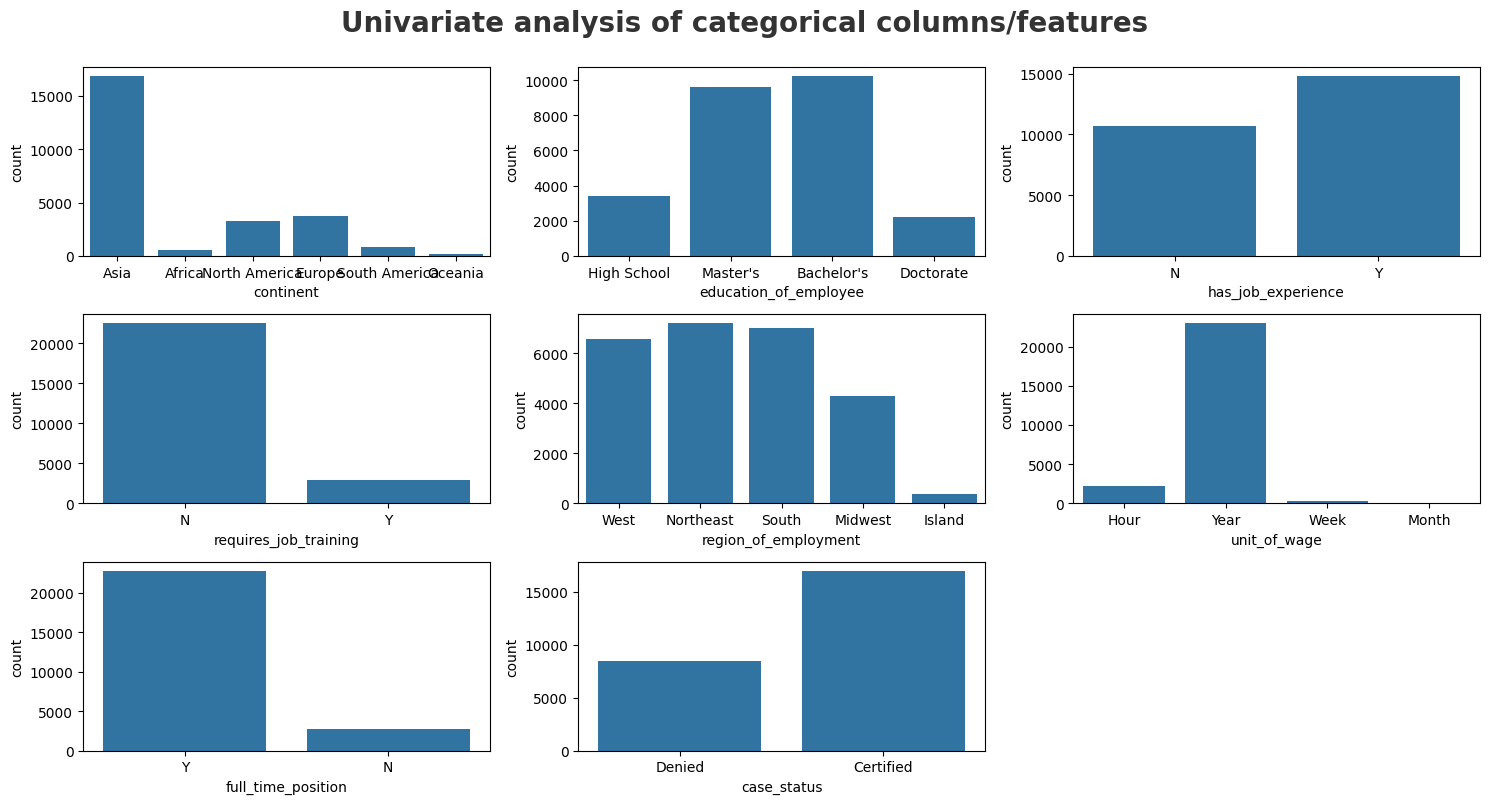

In [114]:
categorical_features.remove('case_id')
plt.figure(figsize=(15,8))
plt.suptitle('Univariate analysis of categorical columns/features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range (0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have signle category dominating.
 - In rest of the columns are balanced.